<a href="https://colab.research.google.com/github/clement-plancq/cesr-multimedia/blob/main/notebooks/seance_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Données multimédia : Python pour le traitement d’images et de données audio

## Master Humanités Numériques du [CESR](https://cesr.univ-tours.fr/)

Clément Plancq (MSH VDL / CITERES)

# Détection d’objets

## Mise en pratique

1. On installe la librairie [ultralytics](https://github.com/ultralytics/ultralytics)

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.0/646.0 kB 8.6 MB/s eta 0:00:00


2. On charge le modèle YOLOv8

In [3]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # pretrained YOLOv8n model

100%|██████████| 6.23M/6.23M [00:00<00:00, 62.5MB/s]


3. On récupère une image

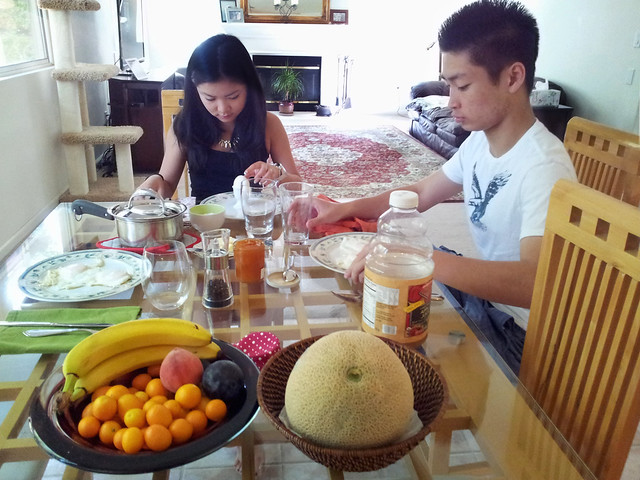

In [4]:
from PIL import Image
from IPython.display import display

!wget https://farm3.staticflickr.com/2851/9370445254_5a68681e60_z.jpg -q -O input.jpg
#!wget https://cesr.univ-tours.fr/medias/photo/cpr-1130x400_1521210968998-jpg -q -O input.jpg
im = Image.open('./input.jpg')
display(im)

4. On applique le modèle et on affiche le résultat


0: 480x640 2 persons, 1 bottle, 5 cups, 3 bowls, 1 banana, 1 apple, 5 oranges, 3 chairs, 1 potted plant, 1 dining table, 364.9ms
Speed: 30.2ms preprocess, 364.9ms inference, 34.0ms postprocess per image at shape (1, 3, 480, 640)


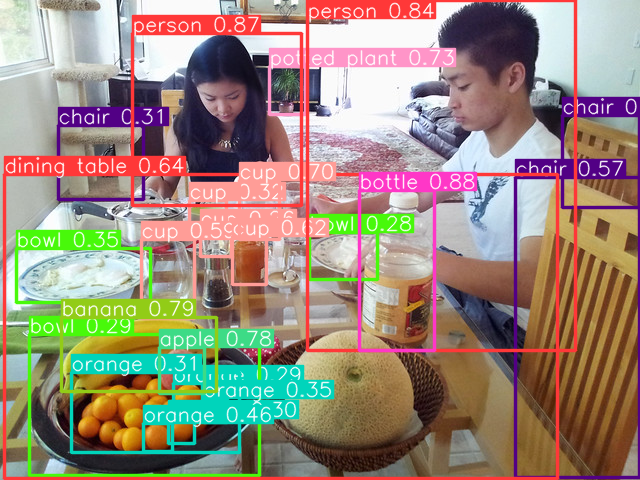

In [5]:
results = model(im)  # on applique le modèle

# Show the results
for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    display(im)  # show image

Voilà ! 4 étapes, une dizaine de lignes de Python et on a de la détection d’objets.  
Des décennies de recherche à portée de main (image processing, computer vision, machine learning, deep learning, …). On n’y comprend pas grand chose mais ça a l’air de fonctionner.

Ce traitement on le doit à YOLO (You Only Look Once). YOLO est décrit dans cet article : [https://arxiv.org/abs/1506.02640](https://arxiv.org/abs/1506.02640)  
Ici nous utilisons YOLOv8 implémenté par ultralytics mais il y a d’autres solutions du même type, par exemple :
- Mediapipe : https://github.com/google/mediapipe (Apache-2.0)
- MMDetection : https://github.com/open-mmlab/mmdetection (Apache-2.0)
- Detectron2 : https://github.com/facebookresearch/detectron2 (Apache-2.0)
- YOLO (You Only Look Once) v8 en 2023 :  https://github.com/ultralytics/ultralytics (AGPL-3.0)

Essayez avec d’autres images pour vous faire une idée de la performance de la détection d’objet.

## Explications

La détection d’objet (*object detection*) est un des domaines de recherche et d’application de la vision par ordinateur (*computer vision*).

Avec YOLO (ou les autres solutions citées) on est à la confluence de la *computer vision* et du *deep learning*

![source : Beltzung B, Pelé M, Renoult JP and Sueur C (2023) Deep learning for studying drawing behavior: A review. Front. Psychol. 14:992541. doi: 10.3389/fpsyg.2023.992541](https://www.frontiersin.org/files/Articles/992541/fpsyg-14-992541-HTML/image_m/fpsyg-14-992541-g001.jpg)
<figcaption>source : Beltzung B, Pelé M, Renoult JP and Sueur C (2023) Deep learning for studying drawing behavior: A review. Front. Psychol. 14:992541. doi: 10.3389/fpsyg.2023.992541</figcaption>

La détection d’objet est une tâche complexe, on peut la décomposer en 3 volets :
- repérer la localisation de l’objet dans l’image. La localisation se fait avec une *bounding box*.
- extraire les caractéristiques de l’objet
- classifier automatiquement chaque objet

### Apprentissage automatique et apprentissage profond

Je vous donne une vue générale pour comprendre ce qu’on met en œuvre ici.  
Si vous voulez aller plus loin je vous conseille fortement
 - la formation FIDLE : https://www.youtube.com/@CNRS-FIDLE
 - l’ouvrage Dive into Deep Learning disponible en ligne (http://d2l.ai/index.html)
 - le cours « Deep Learning for Computer Vision » de Stanford (http://cs231n.stanford.edu/schedule.html)

Pour comprendre l’impact qu’ont eu et qu’ont encore les réseaux de neurones dans la recherche vous pouvez lire :  CARDON Dominique, COINTET Jean-Philippe, MAZIèRES Antoine, « La revanche des neurones. L’invention des machines inductives et la controverse de l’intelligence artificielle », Réseaux, 2018/5 (n° 211), p. 173-220. DOI : 10.3917/res.211.0173. URL : https://www.cairn.info/revue-reseaux-2018-5-page-173.htm

#### Résolution de tâche

En apprentissage automatique on cherche à résoudre des tâches précises. On n’a pas ou pas encore d’intelligence artificielle générale. Ces tâches peuvent être : la détection d’objet, la génération de texte, la reconnaissance d’écriture manuscrite, …

#### Les données au centre

L’apprentissage automatique est centré sur les données. On utilise des méthodes statistiques pour donner à un programme la capacité d’apprendre à résoudre une tâche spécifique à partir d’un jeu de données (*dataset*).  

Il n’y a pas de modélisation de la connaissance *a priori*. Pour apprendre à un modèle à reconnaître une photo de chat on ne cherche pas à définir les caractéristiques d’un chat (il a des moustaches, des oreilles pointues, des coussinets, …). On lui soumet une grande quantité d’images où l’on sait lesquelles sont des chats, lesquelles non et le modèle « apprend ».

Par exemple pour la détection d’objet on va utiliser un ensemble d’images où les objets ont déjà été repérés. Il en faudra beaucoup pour *entraîner* un modèle. L’entraînement est la phase cruciale de l’apprentissage automatique et il repose en grande partie sur les données. Si le volume des données est insuffisant ou si les données sont trop brutées le modèle produit aura des performances dégradées.

Pensez à toutes les fois où vous avez dû cliquer sur des feux de circulation ou des voitures pour accéder à une ressource. Vous avez participé à la constitution de données d’entraînement !

Pour le *machine learning* sur les images, le corpus de données le plus célèbre est ImageNet : https://image-net.org/  
On peut aussi citer le dataset COCO (https://cocodataset.org)

#### Fonction de coût (*loss function*) et optimisation

Comment fonctionne cet entraînement sur les données ?

Le modèle fait des prédictions à partir des données. Par exemple il va déterminer si une image contient un chat ou non. Cette prédiction peut être juste ou fausse.  
La fonction de coût (ou fonction de perte, *loss function*) va quantifier l’écart entre les prédictions du modèle et les valeurs attendues.

![](https://i0.wp.com/neptune.ai/wp-content/uploads/2022/10/neural-network-loss.jpg?resize=768%2C407&ssl=1)
<figcaption>Source : https://neptune.ai/blog/pytorch-loss-functions</figcaption>

On va chercher à réduire au maximum ce coût, cet écart entre les prédictions et les valeurs des données d’entraînement.

Pour cela on va faire un grand nombre d’itérations selon la procédure suivante :

1. Initialisation : Les poids et les biais du modèle (les paramètres internes) sont initialement définis à des valeurs aléatoires.

2. Calcul du Coût : On évalue la performance du modèle en calculant la différence entre les prédictions du modèle et les vraies valeurs.

3. Calcul du Gradient : Le gradient est essentiellement une indication de la direction dans laquelle la fonction de coût augmente le plus rapidement. Il guide la mise à jour des paramètres du modèle.

4. Mise à Jour des Paramètres : Les paramètres du modèle sont ajustés dans la direction opposée au gradient pour réduire la valeur de la fonction de coût.

5. Répétition : Les étapes 2 à 4 sont répétées de manière itérative jusqu'à ce que la fonction de coût soit minimisée autant que possible.


#### Couches

![](https://assets.website-files.com/5ac6b7f2924c652fd013a891/5d52f0972ca59a532d984d0e_s_39292DB9CE2A9400103E176C2ABC438C6A626910E9DBB0D6FBE28EE673C7492C_1565465188363_LearningE_500.jpeg)

On parle de *deep learning* quand il y a au moins trois couches dans un réseau de neurones : la couche d’entrée (les données), la couche de sortie (les prédictions) et les couches cachées entre les deux.

Chaque couche est composée de neurones. Chaque neurone est connecté aux neurones de la couche précédente, cette connexion porte un poids. Ces poids ce sont les paramètres ajustables du modèle qui sont « appris » lors de l’entraînement.

Chaque neurone a une fonction d’activation qui prend en compte les activations des neurones de la couche précédente et les poids des connexions.  
Au final on a des relations très complexes dans le modèle. On parle de non-linéarité des modèles.

On peut s’appuyer sur cette choutte visualisation pour avoir un exemple : [http://playground.tensorflow.org/](http://playground.tensorflow.org/)

## YOLO again

Maintenant nous savons un peu mieux ce que nous manipulons quand nous chargeons un modèle.

Voyons comment nous pouvons exploiter les résultats.

À partir de la documentation (https://docs.ultralytics.com/modes/predict/) nous allons essayer :
- de ne retenir que les objets détectés avec un taux de confiance >= 0.7
- puis nous ajouterons un critére de sélection sur les classes, par exemple que les personnes et les animaux.

In [11]:
# Un seul objet Results dans la liste result
result = results[0]

# On va s'intéresser aux objets Boxes contenu dans le résultat
# (un objet Boxes par objet détecté)
conf_threshold = 0.7 # notre seuil de taux de confiance

for box in result.boxes:
  if box.conf > conf_threshold:
    print(box.conf) # les objets dont les % de confiance sont > à 0.7

tensor([0.8840])
tensor([0.8710])
tensor([0.8448])
tensor([0.7861])
tensor([0.7766])
tensor([0.7295])


In [9]:
# Un seul objet Results dans la liste result
result = results[0]

# On va s'intéresser aux objets Boxes contenu dans le résultat
# (un objet Boxes par objet détecté)
print(f"Il y a {len(result.boxes)} objets détectés par YOLO")
conf_threshold = 0.7 # notre seuil de taux de confiance

for box in result.boxes:
  if box.conf > conf_threshold:
    key = int(box.cls[0]) # on transforme l'attribut cls (Tensor) en valeur entière
    category = result.names[key] # on récupère la catégorie associée à la classe
    print(f"{category} (confiance : {box.conf[0]})")


Il y a 23 objets détectés par YOLO
bottle (confiance : 0.8840004205703735)
person (confiance : 0.8710244297981262)
person (confiance : 0.8448152542114258)
banana (confiance : 0.7860580086708069)
apple (confiance : 0.7766375541687012)
potted plant (confiance : 0.7295233607292175)
